## Setup

In [3]:
!pip install numpy
!pip install pandas
!pip install statsmodels
!pip install pyBigWig

  Obtaining dependency information for pyBigWig from https://files.pythonhosted.org/packages/34/72/f52aaea9c9f8265b259b154a197a3c8e16967ff5e7628468f8f1a8db9971/pyBigWig-0.3.24-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 4.7 MB/s eta 0:00:0000:01


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pyliftover import LiftOver
import pyBigWig
import warnings
from tqdm import tqdm

# Suppress all warnings
warnings.filterwarnings("ignore")

from matplotlib.colors import LinearSegmentedColormap
import mpl_scatter_density

# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

In [2]:
# Specify project directories
data_path = '/oak/stanford/groups/mrivas/projects/wgs-constraint-llm/data/'
results_path = '/oak/stanford/groups/mrivas/projects/wgs-constraint-llm/osthoag/wgs-constraint-llm/results/'

# Specify the file paths
annotation_file_path = data_path + 'gencode.v44.basic.annotation.gtf.gz'
constraint_file_path = data_path + 'gnomad.v4.0.constraint_metrics.tsv'
gerp_file_path = data_path + 'All_hg38_RS.bw'
alpha_missense_file_path = data_path + 'AlphaMissense_hg38.tsv.gz'
hmm_predictions_path = results_path + "HMM_rgc_0.9_over20_chr2_predictions_rgc_wes.tsv.gz"

## Load data

In [4]:
# --- load HMM predictions (once) ---
pred = pd.read_csv(hmm_predictions_path, sep="\t", dtype={"chr":"string"})
# normalize column names if needed
if "position" in pred.columns and "pos" not in pred.columns:
    pred = pred.rename(columns={"position":"pos"})

# (Assuming both datasets are 0-based already per your note)
pred["pos"] = pred["pos"].astype(np.int64)
pred["chr"] = pred["chr"].astype("string")

# helpful: keep a stable column order for final output
pred_cols = pred.columns.tolist()

# --- open bigWig ---
bw = pyBigWig.open(gerp_file_path)
bw_chroms = bw.chroms()  # dict: {chrom: length}

# sort chromosomes nicely
def chr_key(c):
    s = str(c).replace("chr","")
    if s.isdigit(): return (0, int(s))
    order = {"X": 23, "Y": 24, "M": 25, "MT": 25}
    return (1, order.get(s, 1000))

chroms = sorted(pred["chr"].unique().tolist(), key=chr_key)

merged_chunks = []

for chrom in tqdm(chroms, desc="Merging GERP into predictions"):
    if chrom not in bw_chroms:
        # skip chromosomes not in the bigWig
        continue
    chr_len = int(bw_chroms[chrom])

    # rows for this chromosome
    sub = pred.loc[pred["chr"] == chrom].copy()
    if sub.empty:
        continue

    # drop out-of-range just in case
    mask = (sub["pos"] >= 0) & (sub["pos"] < chr_len)
    if not mask.all():
        sub = sub.loc[mask]
    if sub.empty:
        continue

    # Pull the whole chromosome vector once (fast), then index at needed positions
    # Note: pyBigWig returns float64; to halve RAM during this step, cast to float32.
    gerp_vec = np.array(bw.values(chrom, 0, chr_len, numpy=True), dtype=np.float32)

    pos_idx = sub["pos"].to_numpy(dtype=np.int64)
    gerp_vals = gerp_vec[pos_idx]

    sub["GERP_RS"] = gerp_vals

    # optional: drop NaNs if present
    sub = sub.dropna(subset=["GERP_RS"])

    merged_chunks.append(sub)

bw.close()

# --- concatenate all chromosomes into one DataFrame in RAM ---
merged_df = pd.concat(merged_chunks, axis=0, ignore_index=True)

# optional: make chr categorical to save RAM
merged_df["chr"] = merged_df["chr"].astype("category")

print(merged_df.shape)
print(merged_df.head())

# optional: save
# merged_df.to_parquet("predictions_plus_gerp.parquet", index=False)
# or gzipped TSV:
merged_df.to_csv("HMM_rgc_ALL_RS_merged_predictions.tsv.gz", sep="\t", index=False, compression="gzip")


Merging GERP into predictions: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [05:55<00:00, 16.14s/it]


(28922257, 6)
    chr     pos        prob_0    prob_1  observation  GERP_RS
0  chr1  925922  9.218631e-34  1.000000          0.0     1.49
1  chr1  925923  2.515628e-03  0.997484          1.0     4.52
2  chr1  925924  2.518103e-03  0.997482          0.0     4.52
3  chr1  925925  4.543584e-05  0.999955          1.0     2.15
4  chr1  925926  2.596411e-03  0.997404          1.0     4.52


In [3]:
# Get predictions from HMM and GERP
predictions_df = pd.read_csv("HMM_rgc_ALL_RS_merged_predictions.tsv.gz", sep='\t')
predictions_df

,chr,pos,prob_0,prob_1,observation,GERP_RS
0,chr1,925922,9.218631e-34,1.000000,0.0,1.490
1,chr1,925923,2.515628e-03,0.997484,1.0,4.520
2,chr1,925924,2.518103e-03,0.997482,0.0,4.520
3,chr1,925925,4.543584e-05,0.999955,1.0,2.150
4,chr1,925926,2.596411e-03,0.997404,1.0,4.520
...,...,...,...,...,...,...
28922252,chr22,50777975,5.029692e-05,0.999950,1.0,2.970
28922253,chr22,50777976,7.197833e-05,0.999928,1.0,2.970
28922254,chr22,50777977,3.225875e-02,0.967741,1.0,-0.335
28922255,chr22,50777978,5.462209e-01,0.453779,0.0,2.970


In [4]:
# Read the file into a pandas DataFrame
# constraint_df = pd.read_csv(constraint_file_path, sep='\t', usecols=['gene', 'transcript', 'mane_select', 'mis.z_score'])
constraint_df = pd.read_csv(constraint_file_path, sep='\t')

# # Compute the MTR
constraint_df['MTR'] = (constraint_df['mis.obs'] / (constraint_df['mis.obs'] + constraint_df['syn.obs'])) / (constraint_df['mis.exp'] / (constraint_df['mis.exp'] + constraint_df['syn.exp']))

# Drop unnecessary columns
# constraint_df = constraint_df[['gene', 'transcript', 'mane_select', 'mis.z_score', 'lof.z_score', 'MTR']]

constraint_df

,gene,transcript,mane_select,lof_hc_lc.obs,lof_hc_lc.exp,lof_hc_lc.possible,lof_hc_lc.oe,lof_hc_lc.mu,lof_hc_lc.pLI,lof_hc_lc.pNull,...,syn.exp,syn.possible,syn.oe,syn.mu,syn.oe_ci.lower,syn.oe_ci.upper,syn.z_raw,syn.z_score,constraint_flags,MTR
0,A1BG,ENST00000263100,True,45.0,43.008,193.0,1.04630,7.063300e-07,1.572700e-16,0.851710,...,295.680,994.0,1.06870,3.021600e-06,0.974,1.173,-1.181600,-0.644370,[],1.007209
1,A1BG,ENST00000600966,False,24.0,26.243,123.0,0.91451,4.197900e-07,2.496000e-08,0.346550,...,178.730,637.0,0.92876,1.905700e-06,0.818,1.056,0.952380,0.519350,[],1.017737
2,A1BG,NM_130786.4,True,45.0,43.008,193.0,1.04630,7.063300e-07,1.572700e-16,0.851710,...,295.680,994.0,1.06870,3.021600e-06,0.974,1.173,-1.181600,-0.644370,[],1.007209
3,A1CF,ENST00000282641,False,45.0,69.896,352.0,0.64381,9.547100e-07,7.106200e-10,0.002114,...,272.290,1157.0,0.99895,2.007600e-06,0.904,1.104,0.017286,0.009426,[],0.964031
4,A1CF,ENST00000373993,False,43.0,70.294,355.0,0.61172,9.665500e-07,1.009500e-08,0.000938,...,275.790,1173.0,1.00440,2.007600e-06,0.910,1.109,-0.072690,-0.039638,[],0.962264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211267,NaN,ENST00000691540,False,6.0,23.367,101.0,0.25677,5.641100e-07,9.725100e-01,0.000064,...,72.462,273.0,0.97983,1.793000e-06,0.808,1.194,0.171700,0.093629,[],0.910019
211268,NaN,ENST00000691972,False,22.0,38.381,202.0,0.57320,6.304800e-07,1.882800e-04,0.007398,...,139.780,641.0,0.90860,6.413100e-07,0.786,1.053,1.080600,0.589270,[],0.987188
211269,NaN,ENST00000692281,False,46.0,66.376,358.0,0.69302,7.180400e-07,3.574700e-11,0.008375,...,245.080,1115.0,0.84055,8.537600e-07,0.749,0.943,2.496200,1.361200,[],0.980156
211270,NaN,ENST00000692585,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,196.530,703.0,0.95151,3.419600e-06,0.844,1.074,0.679760,0.370680,"[""no_exp_lof""]",1.023435


In [5]:
# Read the GTF file into a pandas DataFrame
gene_df = pd.read_csv(annotation_file_path, sep='\t', comment='#', header=None, 
                      names=['chr', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'], 
                      dtype={'start': int, 'end': int})

# Extract 'gene_id' from attributes
gene_df['gene_id'] = gene_df['attribute'].str.extract(r'gene_id "(.*?)"')

# Extract 'gene_type' from attributes
gene_df['gene_type'] = gene_df['attribute'].str.extract(r'gene_type "(.*?)"')

# Extract 'gene_name' from attributes
gene_df['gene_name'] = gene_df['attribute'].str.extract(r'gene_name "(.*?)"')

# Extract 'transcript_id' from attributes
gene_df['transcript_id'] = gene_df['attribute'].str.extract(r'transcript_id "(.*?)"')

# Extract 'transcript' and 'num' from transcript_id
gene_df[['transcript', 'transcript_num']] = gene_df['transcript_id'].str.split('.', expand=True)

# Extract 'transcript_name' from attributes
gene_df['transcript_name'] = gene_df['attribute'].str.extract(r'transcript_name "(.*?)"')

# Drop the original attribute column
gene_df = gene_df.drop('attribute', axis=1)

# Filter rows for protein-coding regions
gene_df = gene_df[(gene_df['gene_type'] == 'protein_coding') & (gene_df['feature'] == 'CDS')]

gene_df

,chr,source,feature,start,end,score,strand,frame,gene_id,gene_type,gene_name,transcript_id,transcript,transcript_num,transcript_name
60,chr1,HAVANA,CDS,65565,65573,.,+,0,ENSG00000186092.7,protein_coding,OR4F5,ENST00000641515.2,ENST00000641515,2,OR4F5-201
63,chr1,HAVANA,CDS,69037,70005,.,+,0,ENSG00000186092.7,protein_coding,OR4F5,ENST00000641515.2,ENST00000641515,2,OR4F5-201
236,chr1,HAVANA,CDS,450743,451678,.,-,0,ENSG00000284733.2,protein_coding,OR4F29,ENST00000426406.4,ENST00000426406,4,OR4F29-201
304,chr1,HAVANA,CDS,685719,686654,.,-,0,ENSG00000284662.2,protein_coding,OR4F16,ENST00000332831.5,ENST00000332831,5,OR4F16-201
524,chr1,HAVANA,CDS,924432,924948,.,+,0,ENSG00000187634.13,protein_coding,SAMD11,ENST00000616016.5,ENST00000616016,5,SAMD11-209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1998488,chrM,ENSEMBL,CDS,10470,10763,.,+,0,ENSG00000212907.2,protein_coding,MT-ND4L,ENST00000361335.1,ENST00000361335,1,MT-ND4L-201
1998495,chrM,ENSEMBL,CDS,10760,12137,.,+,0,ENSG00000198886.2,protein_coding,MT-ND4,ENST00000361381.2,ENST00000361381,2,MT-ND4-201
1998509,chrM,ENSEMBL,CDS,12337,14145,.,+,0,ENSG00000198786.2,protein_coding,MT-ND5,ENST00000361567.2,ENST00000361567,2,MT-ND5-201
1998515,chrM,ENSEMBL,CDS,14149,14673,.,-,0,ENSG00000198695.2,protein_coding,MT-ND6,ENST00000361681.2,ENST00000361681,2,MT-ND6-201


In [6]:
gene_constraint_df = pd.merge(gene_df, constraint_df, left_on=['gene_name', 'transcript'], right_on=['gene', 'transcript'], how='inner')
gene_constraint_df['length'] = abs(gene_constraint_df['end'] - gene_constraint_df['start']) + 1
gene_constraint_df

,chr,source,feature,start,end,score,strand,frame,gene_id,gene_type,...,syn.possible,syn.oe,syn.mu,syn.oe_ci.lower,syn.oe_ci.upper,syn.z_raw,syn.z_score,constraint_flags,MTR,length
0,chr1,HAVANA,CDS,65565,65573,.,+,0,ENSG00000186092.7,protein_coding,...,22.0,0.94816,3.428000e-07,0.536,1.694,0.14086,0.076812,[],0.972060,9
1,chr1,HAVANA,CDS,69037,70005,.,+,0,ENSG00000186092.7,protein_coding,...,22.0,0.94816,3.428000e-07,0.536,1.694,0.14086,0.076812,[],0.972060,969
2,chr1,HAVANA,CDS,924432,924948,.,+,0,ENSG00000187634.13,protein_coding,...,1251.0,1.67150,4.036100e-06,1.563,1.788,-12.77600,-6.966700,"[""outlier_mis"",""outlier_syn""]",0.985311,517
3,chr1,HAVANA,CDS,925922,926013,.,+,2,ENSG00000187634.13,protein_coding,...,1251.0,1.67150,4.036100e-06,1.563,1.788,-12.77600,-6.966700,"[""outlier_mis"",""outlier_syn""]",0.985311,92
4,chr1,HAVANA,CDS,930155,930336,.,+,0,ENSG00000187634.13,protein_coding,...,1251.0,1.67150,4.036100e-06,1.563,1.788,-12.77600,-6.966700,"[""outlier_mis"",""outlier_syn""]",0.985311,182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585694,chr22,HAVANA,CDS,50779055,50779121,.,-,1,ENSG00000079974.19,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[""no_exp_lof"",""no_exp_mis"",""no_exp_syn"",""no_va...",NaN,67
585695,chr22,HAVANA,CDS,50782188,50782294,.,-,0,ENSG00000079974.19,protein_coding,...,103.0,1.03390,4.913600e-07,0.776,1.395,-0.18564,-0.101230,[],0.962344,107
585696,chr22,HAVANA,CDS,50777952,50777981,.,-,1,ENSG00000079974.19,protein_coding,...,103.0,1.03390,4.913600e-07,0.776,1.395,-0.18564,-0.101230,[],0.962344,30
585697,chr22,HAVANA,CDS,50776670,50776749,.,-,1,ENSG00000079974.19,protein_coding,...,103.0,1.03390,4.913600e-07,0.776,1.395,-0.18564,-0.101230,[],0.962344,80


## Evaluate relationship between different gnomAD and HMM constraint metrics

1. Aggregate HMM constraint predictions over each gene
2. Compare to an existing constraint metric from gnomAD using a GLM
3. Plot the relationship

### HMM vs GERP

In [6]:
merged_df.dropna(subset=["GERP_RS"], inplace=True)

# Define X and y
X = merged_df["prob_0"]
y = merged_df["GERP_RS"]

# Add constant term for intercept
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Print R-squared
print("R-squared:", model.rsquared)

# Optionally print full summary
print(model.summary())

R-squared: 0.006309142144552027
                            OLS Regression Results                            
Dep. Variable:                GERP_RS   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                 1.836e+05
Date:                Wed, 13 Aug 2025   Prob (F-statistic):               0.00
Time:                        19:00:07   Log-Likelihood:            -7.8550e+07
No. Observations:            28922257   AIC:                         1.571e+08
Df Residuals:                28922255   BIC:                         1.571e+08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.306

In [7]:
results = []
for chrom, df_chrom in merged_df.groupby("chr"):
    if len(df_chrom) < 10:
        continue
    X = sm.add_constant(df_chrom["prob_0"])
    y = df_chrom["GERP_RS"]
    model = sm.OLS(y, X).fit()
    results.append({
        "chr": chrom,
        "n": len(df_chrom),
        "r_squared": model.rsquared
    })

per_chrom_results = pd.DataFrame(results)
print(per_chrom_results)

      chr        n  r_squared
0    chr1  3058013   0.006218
1   chr10  1166868   0.005759
2   chr11  1826011   0.006193
3   chr12  1595038   0.006028
4   chr13   546314   0.005224
5   chr14   951575   0.006866
6   chr15  1031294   0.004961
7   chr16  1246243   0.007413
8   chr17  1752338   0.007268
9   chr18   472321   0.004875
10  chr19  2020553   0.005677
11   chr2  2196160   0.005175
12  chr20   734993   0.009102
13  chr21   286761   0.005684
14  chr22   627383   0.006179
15   chr3  1771711   0.005422
16   chr4  1164086   0.005623
17   chr5  1388151   0.006789
18   chr6  1539481   0.004493
19   chr7  1350607   0.004443
20   chr8   994491   0.008149
21   chr9  1201865   0.006851


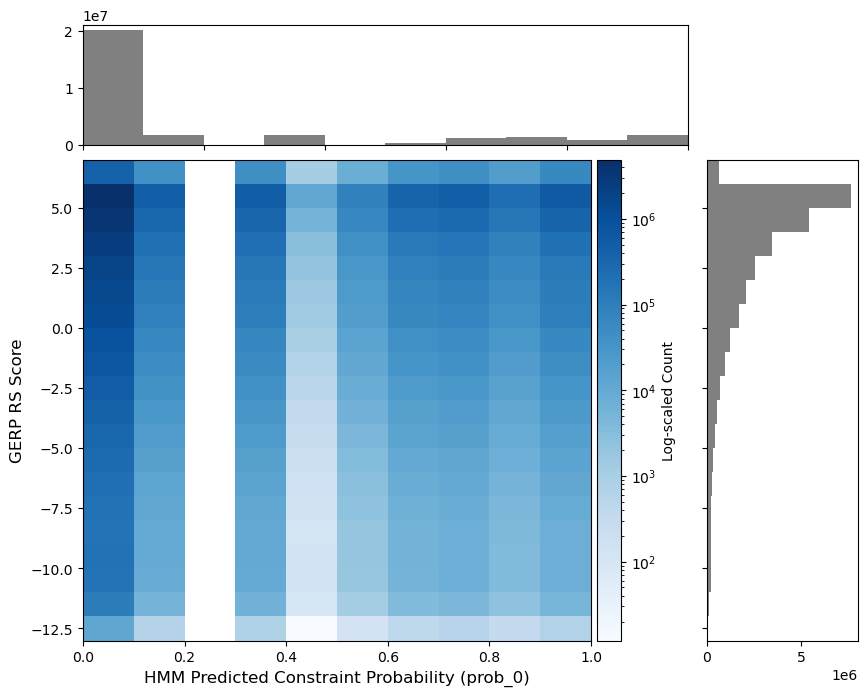

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import gridspec

# Load the data
predictions_df = pd.read_csv("HMM_rgc_ALL_RS_merged_predictions.tsv.gz", sep='\t')
predictions_df = predictions_df.dropna(subset=['prob_0', 'GERP_RS'])

# Define bins
x_bins = np.arange(0, 1.1, 0.1)  # prob_0 bins of width 0.1
y_min = int(np.floor(predictions_df['GERP_RS'].min()))
y_max = int(np.ceil(predictions_df['GERP_RS'].max()))
y_bins = np.arange(y_min, y_max + 1, 1)  # GERP_RS bins of width 1

# Set up joint plot layout using GridSpec
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                       wspace=0.05, hspace=0.05)

ax_joint = fig.add_subplot(gs[1, 0])
ax_marg_x = fig.add_subplot(gs[0, 0], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs[1, 1], sharey=ax_joint)

# Joint 2D histogram
hist = ax_joint.hist2d(
    predictions_df['prob_0'],
    predictions_df['GERP_RS'],
    bins=[x_bins, y_bins],
    norm=LogNorm(),
    cmap='Blues'
)

# Marginal histograms
ax_marg_x.hist(predictions_df['prob_0'], bins=x_bins, color='gray')
ax_marg_y.hist(predictions_df['GERP_RS'], bins=y_bins, orientation='horizontal', color='gray')

# Hide tick labels for marginal plots
ax_marg_x.tick_params(axis='x', labelbottom=False)
ax_marg_y.tick_params(axis='y', labelleft=False)

# Labels and title
ax_joint.set_xlabel('HMM Predicted Constraint Probability (prob_0)', fontsize=12)
ax_joint.set_ylabel('GERP RS Score', fontsize=12)
ax_joint.set_title('Joint and Marginal Distributions', fontsize=14, fontweight='bold', pad=20)

# Colorbar
cb = plt.colorbar(hist[3], ax=ax_joint, pad=0.01)
cb.set_label('Log-scaled Count')

plt.tight_layout()
plt.show()


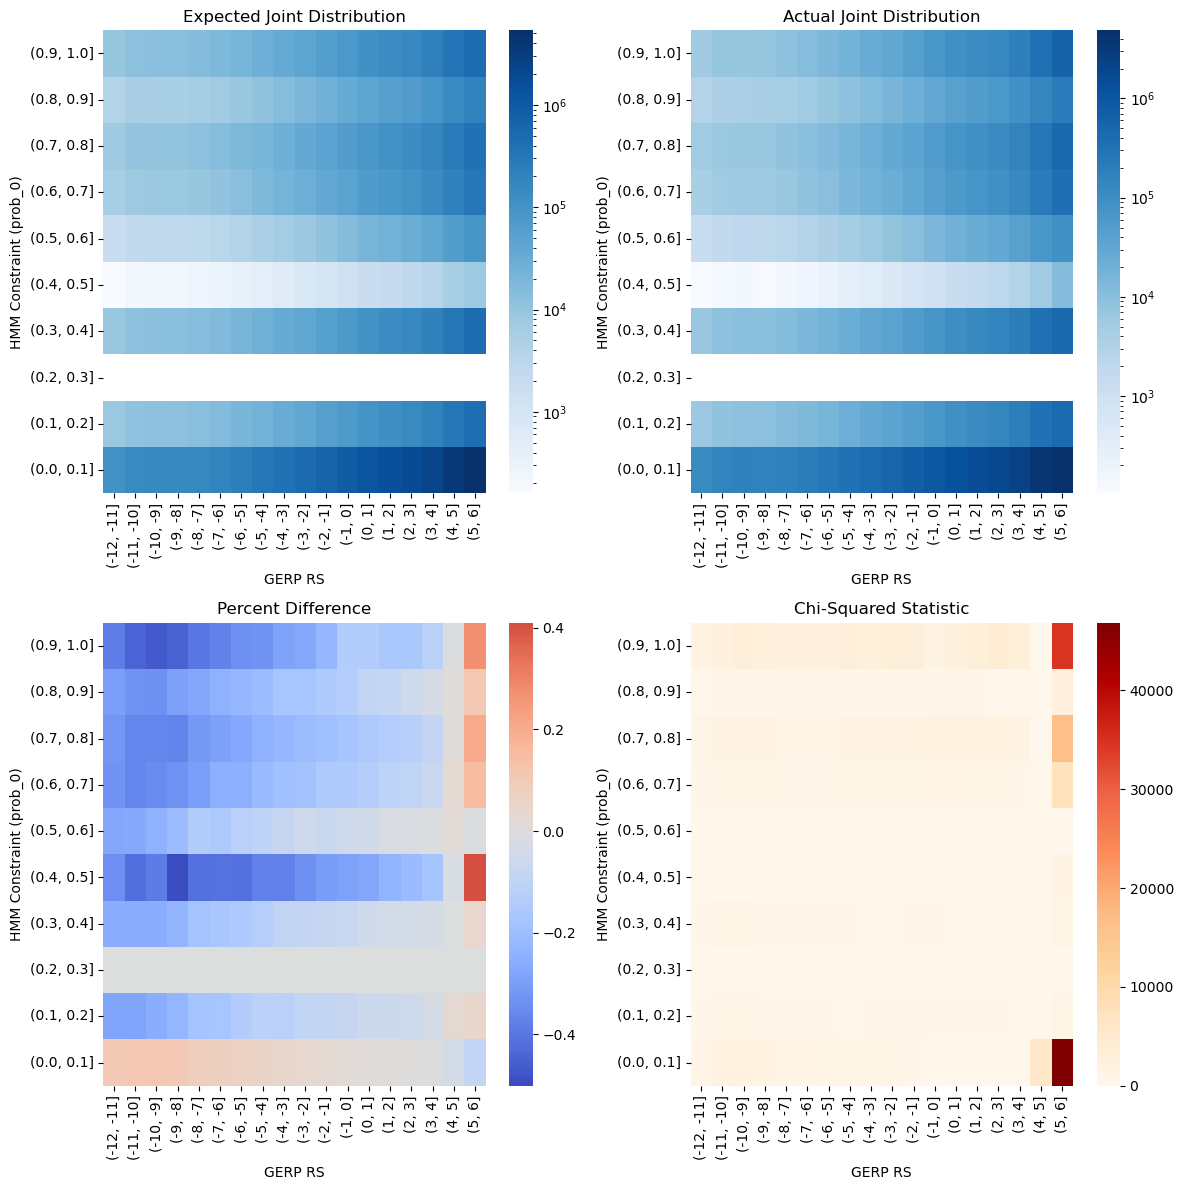

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Load HMM+GERP predictions
predictions_df = pd.read_csv("HMM_rgc_ALL_RS_merged_predictions.tsv.gz", sep='\t')

# Drop missing values
predictions_df = predictions_df.dropna(subset=['prob_0', 'GERP_RS'])

# Define bin edges
prob_bins = np.arange(0, 1.1, 0.1)     # HMM constraint (prob_0) in bins of 0.1
gerp_bins = np.arange(-12, 7, 1)       # GERP RS in bins of width 1

# Bin the data
predictions_df['prob_0_bin'] = pd.cut(predictions_df['prob_0'], bins=prob_bins, precision=2)
predictions_df['gerp_bin'] = pd.cut(predictions_df['GERP_RS'], bins=gerp_bins, precision=2)

# Marginal distributions
marginal_prob = predictions_df['prob_0_bin'].value_counts(normalize=True).sort_index()
marginal_gerp = predictions_df['gerp_bin'].value_counts(normalize=True).sort_index()

# Expected joint under independence
expected_joint = np.outer(marginal_prob, marginal_gerp) * len(predictions_df)

# Actual joint distribution
actual_joint = predictions_df[['prob_0_bin', 'gerp_bin']].value_counts().sort_index()
actual_joint = np.array([
    [actual_joint.get((prob_bin, gerp_bin), 0) for gerp_bin in marginal_gerp.index]
    for prob_bin in marginal_prob.index
])

# Percent difference and chi-square
percent_diff = (actual_joint - expected_joint) / expected_joint
percent_diff = np.nan_to_num(percent_diff)

chi_sqr = (expected_joint - actual_joint) ** 2 / expected_joint
chi_sqr = np.nan_to_num(chi_sqr)

# Plot
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# Expected
sns.heatmap(expected_joint, cmap='Blues', norm=LogNorm(), cbar=True,
            xticklabels=marginal_gerp.index, yticklabels=marginal_prob.index, ax=axs[0, 0])
axs[0, 0].set_title('Expected Joint Distribution')
axs[0, 0].set_xlabel('GERP RS')
axs[0, 0].set_ylabel('HMM Constraint (prob_0)')
axs[0, 0].invert_yaxis()

# Actual
sns.heatmap(actual_joint, cmap='Blues', norm=LogNorm(), cbar=True,
            xticklabels=marginal_gerp.index, yticklabels=marginal_prob.index, ax=axs[0, 1])
axs[0, 1].set_title('Actual Joint Distribution')
axs[0, 1].set_xlabel('GERP RS')
axs[0, 1].set_ylabel('HMM Constraint (prob_0)')
axs[0, 1].invert_yaxis()

# Percent diff
sns.heatmap(percent_diff, cmap='coolwarm', center=0, cbar=True,
            xticklabels=marginal_gerp.index, yticklabels=marginal_prob.index, ax=axs[1, 0])
axs[1, 0].set_title('Percent Difference')
axs[1, 0].set_xlabel('GERP RS')
axs[1, 0].set_ylabel('HMM Constraint (prob_0)')
axs[1, 0].invert_yaxis()

# Chi-squared
sns.heatmap(chi_sqr, cmap='OrRd', cbar=True,
            xticklabels=marginal_gerp.index, yticklabels=marginal_prob.index, ax=axs[1, 1])
axs[1, 1].set_title('Chi-Squared Statistic')
axs[1, 1].set_xlabel('GERP RS')
axs[1, 1].set_ylabel('HMM Constraint (prob_0)')
axs[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()


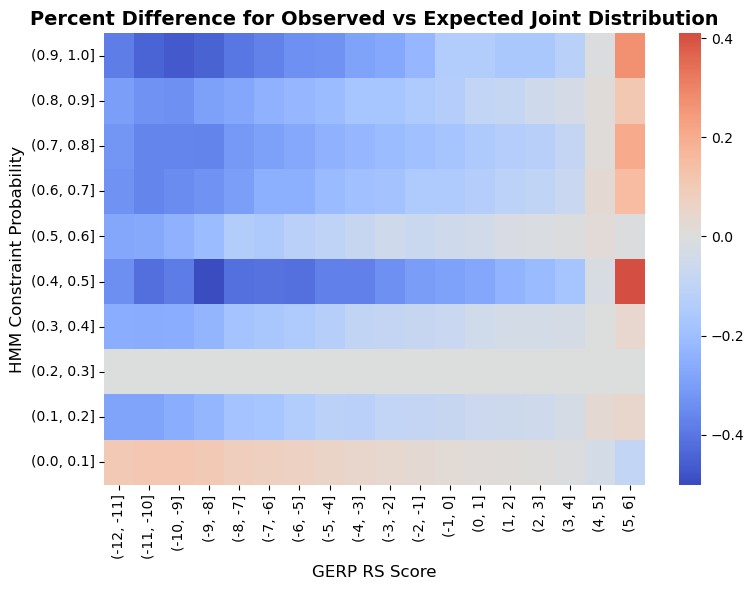

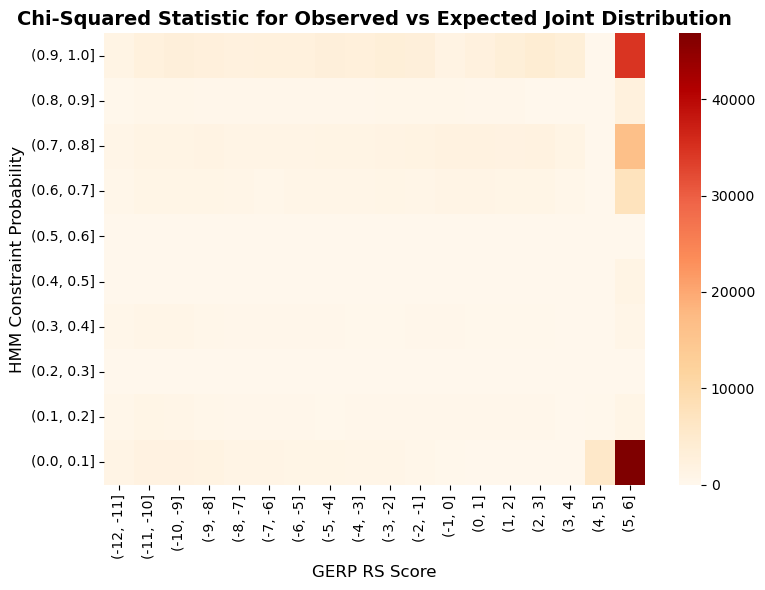

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# (Assuming you already have predictions_df, binning, and chi_sqr calculated...)
# Create figure
plt.figure(figsize=(8, 6))

# Plot chi-squared statistic with log scale
sns.heatmap(
    percent_diff,
#     norm=LogNorm(vmin=1e-1, vmax=np.max(chi_sqr)),  # Log scale with reasonable floor
    xticklabels=marginal_gerp.index,
    yticklabels=marginal_prob.index,
    cmap='coolwarm',
    center=0,
    cbar=True
)

# Axis labels
plt.xlabel('GERP RS Score', fontsize=12)
plt.ylabel('HMM Constraint Probability', fontsize=12)
plt.title('Percent Difference for Observed vs Expected Joint Distribution', fontsize=14, fontweight='bold')

# Optional: invert y-axis to match previous convention
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Create figure
plt.figure(figsize=(8, 6))

# Plot chi-squared statistic with log scale
sns.heatmap(
    chi_sqr,
    cmap='OrRd',
#     norm=LogNorm(vmin=1e-1, vmax=np.max(chi_sqr)),  # Log scale with reasonable floor
    xticklabels=marginal_gerp.index,
    yticklabels=marginal_prob.index,
    cbar=True
)

# Axis labels
plt.xlabel('GERP RS Score', fontsize=12)
plt.ylabel('HMM Constraint Probability', fontsize=12)
plt.title('Chi-Squared Statistic for Observed vs Expected Joint Distribution', fontsize=14, fontweight='bold')

# Optional: invert y-axis to match previous convention
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [ ]:
xticklabels = [f'{i:.1f}' for i in np.arange(0, 1.1, 0.1)]
yticklabels = [f'{i:.1f}' for i in np.arange(0, 1.1, 0.1)]

fig, ax1 = plt.subplots(1, figsize=(7, 6))

# Plot actual joint distribution with log scale
ax1 = sns.heatmap(actual_joint, cmap='Blues', annot=False, fmt=".3f", cbar=True, norm=LogNorm(), ax=ax1)
ax1.set_title('Observed Joint Distribution', fontsize=14)
ax1.set_xlabel('RGC Constraint Probability', fontsize=12)
ax1.set_ylabel('AoU Constraint Probability', fontsize=12)
ax1.invert_yaxis()
ax1.set_xticks(range(11))
ax1.set_xticklabels(xticklabels)
ax1.set_yticks(range(11))
ax1.set_yticklabels(yticklabels)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.savefig(results_path + "Figure 2a: observed joint distribution of RGC vs AoU WES constraint predictions")
plt.show()

fig, ax2 = plt.subplots(1, figsize=(7, 6))

# Plot chi-squared statistic
ax2 = sns.heatmap(chi_sqr, cmap='Blues', annot=False, fmt=".3f", cbar=True, ax=ax2)
ax2.set_title('$\chi^2$ for Observed vs Expected Joint Distribution', y=1, x=0.55, fontsize=14)
ax2.set_xlabel('RGC Constraint Probability', fontsize=12)
ax2.set_ylabel('AoU Constraint Probability', fontsize=12)
ax2.invert_yaxis()
ax2.set_xticks(range(11))
ax2.set_xticklabels(xticklabels)
ax2.set_yticks(range(11))
ax2.set_yticklabels(yticklabels)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.savefig(results_path + "Figure 2b: chi-square statistics of RGC vs AoU WES constraint predictions")
plt.show()

### HMM vs MTR and gnomAD Missense/LoF zscore

In [7]:
# Function to calculate the overlap proportion for a single row
def calculate_overlap(row, chr_pos_dict):
    positions = chr_pos_dict[row['chr']]
    return np.sum((row['start'] <= positions) & (positions <= row['end'])) / row['length']

# Filter for the positions with probability > 0.8 of observing a 0
pos_over_80_dict = {'chr' + str(chromnum):
                    predictions_df[(predictions_df['chr'] == 'chr' + str(chromnum)) & (predictions_df['prob_0'] > 0.8)]['pos'].to_numpy()
                    for chromnum in range(1,23)}


# Apply the function to each row
gene_constraint_df['proportion_over_80'] = gene_constraint_df.apply(lambda row: calculate_overlap(row, pos_over_80_dict), axis=1)

# Filter for the positions with probability > 0.6 of observing a 0
pos_over_60_dict = {'chr' + str(chromnum):
                    predictions_df[(predictions_df['chr'] == 'chr' + str(chromnum)) & (predictions_df['prob_0'] > 0.6)]['pos'].to_numpy()
                    for chromnum in range(1,23)}

# Apply the function to each row
gene_constraint_df['proportion_over_60'] = gene_constraint_df.apply(lambda row: calculate_overlap(row, pos_over_60_dict), axis=1)

# Filter for the positions with probability > 0.5 of observing a 0
pos_over_50_dict = {'chr' + str(chromnum):
                    predictions_df[(predictions_df['chr'] == 'chr' + str(chromnum)) & (predictions_df['prob_0'] > 0.5)]['pos'].to_numpy()
                    for chromnum in range(1,23)}

# Apply the function to each row
gene_constraint_df['proportion_over_50'] = gene_constraint_df.apply(lambda row: calculate_overlap(row, pos_over_50_dict), axis=1)

# Display the result
gene_constraint_df


KeyboardInterrupt



In [8]:
# Drop rows with missing or NaN values
filtered_df = gene_constraint_df.dropna(subset=['mis.z_score', 'proportion_over_80'])

X = filtered_df['mis.z_score']
X = sm.add_constant(X)
y = filtered_df['proportion_over_80']

# Fit the logistic regression model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     proportion_over_80   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                 1.338e+05
Date:                Tue, 11 Mar 2025   Prob (F-statistic):               0.00
Time:                        15:51:59   Log-Likelihood:             6.8395e+05
No. Observations:              585506   AIC:                        -1.368e+06
Df Residuals:                  585504   BIC:                        -1.368e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0604      0.000    487.974      

KeyError: 'proportion_over_80'

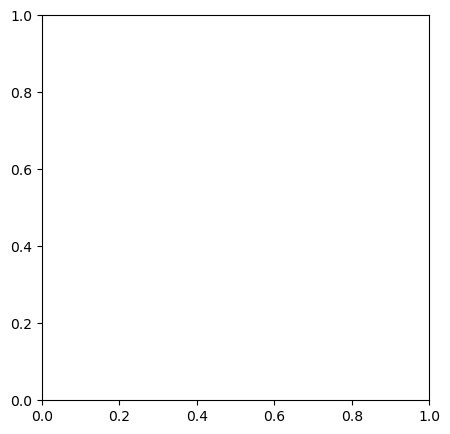

In [12]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='scatter_density')
density = ax.scatter_density(gene_constraint_df['proportion_over_80'], gene_constraint_df['mis.z_score'], cmap=white_viridis)
ax.set_xlabel('Proportion of gene with $\mathbb{P}(0) > 0.8$')
# ax.set_ylabel('Missense Tolerance Ratio z-score')
ax.set_ylabel('Z-score of observed vs expected')
ax.set_xlim([0, 0.5])  # Adjust xlim if needed
ax.set_ylim([-10, 10])   # Adjust ylim if needed
# ax.set_title('Constraint Predictions vs MTR per gene')
ax.set_title('HMM Constraint Predictions vs gnomAD Z-score per gene')
fig.colorbar(density, label='Number of points per pixel')
ax.text(0.3, -7, '$R^2=0.186$', fontsize=10)
plt.show()

In [10]:
# Drop rows with missing or NaN values
filtered_df = gene_constraint_df.dropna(subset=['lof.z_score', 'proportion_over_60'])

X = filtered_df['lof.z_score']
X = sm.add_constant(X)
y = filtered_df['proportion_over_60']

# Fit the logistic regression model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     proportion_over_60   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                 7.202e+04
Date:                Tue, 11 Mar 2025   Prob (F-statistic):               0.00
Time:                        15:52:02   Log-Likelihood:             4.2415e+05
No. Observations:              584172   AIC:                        -8.483e+05
Df Residuals:                  584170   BIC:                        -8.483e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1277      0.000    564.501      

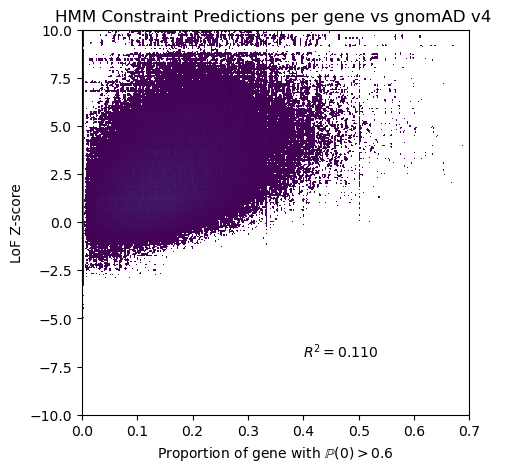

In [11]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='scatter_density')
density = ax.scatter_density(gene_constraint_df['proportion_over_60'], gene_constraint_df['lof.z_score'], cmap=white_viridis)
ax.set_xlabel('Proportion of gene with $\mathbb{P}(0) > 0.6$')
# ax.set_ylabel('Missense Tolerance Ratio z-score')
ax.set_ylabel('LoF Z-score')
ax.set_xlim([0, 0.7])  # Adjust xlim if needed
ax.set_ylim([-10, 10])   # Adjust ylim if needed
# ax.set_title('Constraint Predictions vs MTR per gene')
ax.set_title('HMM Constraint Predictions per gene vs gnomAD v4 ')
# fig.colorbar(density, label='Number of points per pix/el')
ax.text(0.4, -7, '$R^2=0.110$', fontsize=10)
plt.show()

In [12]:
# Drop rows with missing or NaN values
filtered_df = gene_constraint_df.dropna(subset=['mis.z_score', 'proportion_over_60'])

X = filtered_df['mis.z_score']
X = sm.add_constant(X)
y = filtered_df['proportion_over_60']

# Fit the logistic regression model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     proportion_over_60   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                 1.525e+05
Date:                Tue, 11 Mar 2025   Prob (F-statistic):               0.00
Time:                        15:52:04   Log-Likelihood:             4.5839e+05
No. Observations:              585506   AIC:                        -9.168e+05
Df Residuals:                  585504   BIC:                        -9.168e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1291      0.000    709.185      

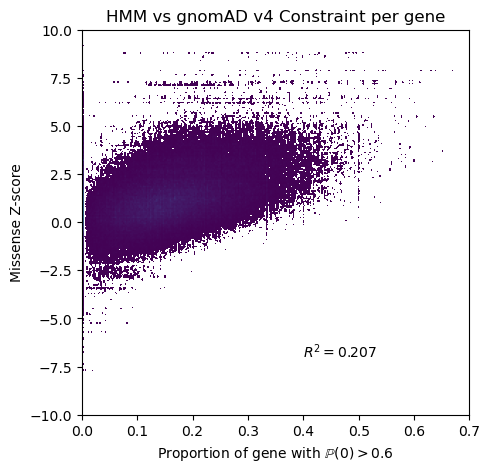

In [13]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='scatter_density')
density = ax.scatter_density(gene_constraint_df['proportion_over_60'], gene_constraint_df['mis.z_score'], cmap=white_viridis)
ax.set_xlabel('Proportion of gene with $\mathbb{P}(0) > 0.6$')
# ax.set_ylabel('Missense Tolerance Ratio z-score')
ax.set_ylabel('Missense Z-score')
ax.set_xlim([0, 0.7])  # Adjust xlim if needed
ax.set_ylim([-10, 10])   # Adjust ylim if needed
# ax.set_title('Constraint Predictions vs MTR per gene')
ax.set_title('HMM vs gnomAD v4 Constraint per gene')
# fig.colorbar(density, label='Number of points per pix/el')
ax.text(0.4, -7, '$R^2=0.207$', fontsize=10)
plt.savefig(results_path + "Figure 3a: HMM vs gnomAD v4 constraint per gene")
plt.show()

In [14]:
# Drop rows with missing or NaN values
filtered_df = gene_constraint_df.dropna(subset=['MTR', 'proportion_over_60'])

X = filtered_df['MTR']
X = sm.add_constant(X)
y = filtered_df['proportion_over_60']

# Fit the logistic regression model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     proportion_over_60   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                 1.046e+05
Date:                Tue, 11 Mar 2025   Prob (F-statistic):               0.00
Time:                        15:52:07   Log-Likelihood:             4.3881e+05
No. Observations:              585403   AIC:                        -8.776e+05
Df Residuals:                  585401   BIC:                        -8.776e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8950      0.002    399.615      0.0

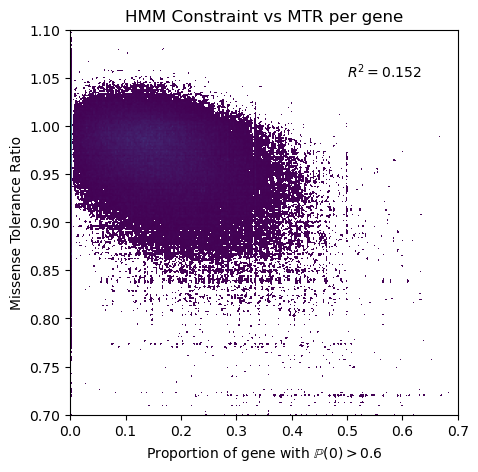

In [15]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='scatter_density')
density = ax.scatter_density(gene_constraint_df['proportion_over_60'], gene_constraint_df['MTR'], cmap=white_viridis)
ax.set_xlabel('Proportion of gene with $\mathbb{P}(0) > 0.6$')
ax.set_ylabel('Missense Tolerance Ratio')
# ax.set_ylabel('Z-score of observed vs expected')
ax.set_xlim([0, 0.7])  # Adjust xlim if needed
ax.set_ylim([0.7, 1.1])   # Adjust ylim if needed
ax.set_title('HMM Constraint vs MTR per gene')
# ax.set_title('HMM Constraint Predictions vs gnomAD Z-score per gene')
# fig.colorbar(density, label='Number of points per pixel')
ax.text(0.5, 1.05, '$R^2=0.152$', fontsize=10)
plt.savefig(results_path + "Figure 3b: HMM vs MTR per gene")
plt.show()

### threshold 0.5

In [28]:
# Function to calculate the overlap proportion for a single row
def calculate_overlap(row, chr_pos_dict):
    positions = chr_pos_dict[row['chr']]
    return np.sum((row['start'] <= positions) & (positions <= row['end'])) / row['length']

# Filter for the positions with probability > 0.5 of observing a 0
pos_over_50_dict = {'chr' + str(chromnum):
                    predictions_df[(predictions_df['chr'] == 'chr' + str(chromnum)) & (predictions_df['prob_0'] > 0.5)]['pos'].to_numpy()
                    for chromnum in range(1,23)}

# Apply the function to each row
gene_constraint_df['proportion_over_50'] = gene_constraint_df.apply(lambda row: calculate_overlap(row, pos_over_50_dict), axis=1)

# Display the result
gene_constraint_df

,chr,source,feature,start,end,score,strand,frame,gene_id,gene_type,...,syn.oe,syn.mu,syn.oe_ci.lower,syn.oe_ci.upper,syn.z_raw,syn.z_score,constraint_flags,MTR,length,proportion_over_50
0,chr1,HAVANA,CDS,65565,65573,.,+,0,ENSG00000186092.7,protein_coding,...,0.94816,3.428000e-07,0.536,1.694,0.14086,0.076812,[],0.972060,9,0.000000
1,chr1,HAVANA,CDS,69037,70005,.,+,0,ENSG00000186092.7,protein_coding,...,0.94816,3.428000e-07,0.536,1.694,0.14086,0.076812,[],0.972060,969,0.000000
2,chr1,HAVANA,CDS,924432,924948,.,+,0,ENSG00000187634.13,protein_coding,...,1.67150,4.036100e-06,1.563,1.788,-12.77600,-6.966700,"[""outlier_mis"",""outlier_syn""]",0.985311,517,0.000000
3,chr1,HAVANA,CDS,925922,926013,.,+,2,ENSG00000187634.13,protein_coding,...,1.67150,4.036100e-06,1.563,1.788,-12.77600,-6.966700,"[""outlier_mis"",""outlier_syn""]",0.985311,92,0.076087
4,chr1,HAVANA,CDS,930155,930336,.,+,0,ENSG00000187634.13,protein_coding,...,1.67150,4.036100e-06,1.563,1.788,-12.77600,-6.966700,"[""outlier_mis"",""outlier_syn""]",0.985311,182,0.049451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585694,chr22,HAVANA,CDS,50779055,50779121,.,-,1,ENSG00000079974.19,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,"[""no_exp_lof"",""no_exp_mis"",""no_exp_syn"",""no_va...",NaN,67,0.000000
585695,chr22,HAVANA,CDS,50782188,50782294,.,-,0,ENSG00000079974.19,protein_coding,...,1.03390,4.913600e-07,0.776,1.395,-0.18564,-0.101230,[],0.962344,107,0.000000
585696,chr22,HAVANA,CDS,50777952,50777981,.,-,1,ENSG00000079974.19,protein_coding,...,1.03390,4.913600e-07,0.776,1.395,-0.18564,-0.101230,[],0.962344,30,0.366667
585697,chr22,HAVANA,CDS,50776670,50776749,.,-,1,ENSG00000079974.19,protein_coding,...,1.03390,4.913600e-07,0.776,1.395,-0.18564,-0.101230,[],0.962344,80,0.312500


In [47]:
# Drop rows with missing or NaN values
filtered_df = gene_constraint_df.dropna(subset=['mis.z_score', 'proportion_over_50'])

X = filtered_df['mis.z_score']
X = sm.add_constant(X)
y = filtered_df['proportion_over_50']

# Fit the logistic regression model
model = sm.OLS(y, X).fit()
rsquared = model.rsquared

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     proportion_over_50   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                 1.497e+05
Date:                Mon, 06 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:13:25   Log-Likelihood:             4.5445e+05
No. Observations:              585506   AIC:                        -9.089e+05
Df Residuals:                  585504   BIC:                        -9.089e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1389      0.000    757.998      

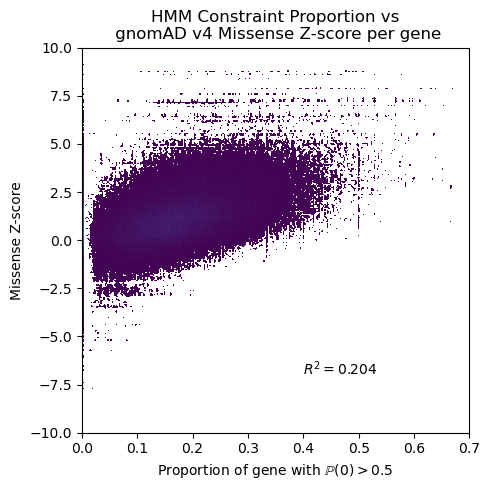

In [51]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='scatter_density')
density = ax.scatter_density(gene_constraint_df['proportion_over_50'], gene_constraint_df['mis.z_score'], cmap=white_viridis)
ax.set_xlabel('Proportion of gene with $\mathbb{P}(0) > 0.5$')
# ax.set_ylabel('Missense Tolerance Ratio z-score')
ax.set_ylabel('Missense Z-score')
ax.set_xlim([0, 0.7])  # Adjust xlim if needed
ax.set_ylim([-10, 10])   # Adjust ylim if needed
# ax.set_title('Constraint Predictions vs MTR per gene')
ax.set_title('HMM Constraint Proportion vs\n gnomAD v4 Missense Z-score per gene')
# fig.colorbar(density, label='Number of points per pix/el')
ax.text(0.4, -7, f'$R^2={round(rsquared,3)}$', fontsize=10)
plt.savefig(results_path + "Figure 3a: HMM vs gnomAD missense z-score per gene")
plt.show()

In [41]:
# Drop rows with missing or NaN values
filtered_df = gene_constraint_df.dropna(subset=['lof.z_score', 'proportion_over_50'])

X = filtered_df['lof.z_score']
X = sm.add_constant(X)
y = filtered_df['proportion_over_50']

# Fit the logistic regression model
model = sm.OLS(y, X).fit()
rsquared = model.rsquared

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     proportion_over_50   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                 7.157e+04
Date:                Mon, 06 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:11:13   Log-Likelihood:             4.2117e+05
No. Observations:              584172   AIC:                        -8.423e+05
Df Residuals:                  584170   BIC:                        -8.423e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1373      0.000    603.927      

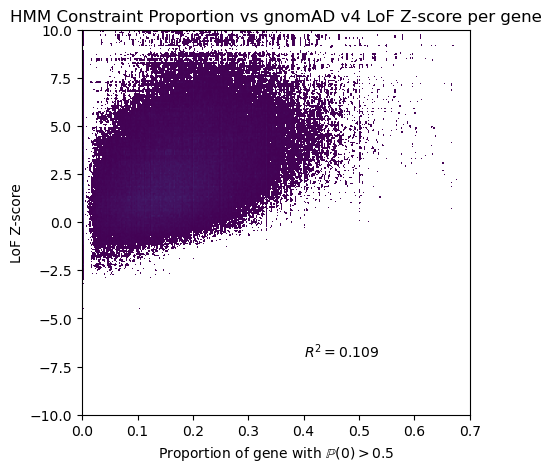

In [42]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='scatter_density')
density = ax.scatter_density(gene_constraint_df['proportion_over_50'], gene_constraint_df['lof.z_score'], cmap=white_viridis)
ax.set_xlabel('Proportion of gene with $\mathbb{P}(0) > 0.5$')
ax.set_ylabel('LoF Z-score')
ax.set_xlim([0, 0.7])  # Adjust xlim if needed
ax.set_ylim([-10, 10])   # Adjust ylim if needed
# ax.set_title('Constraint Predictions vs MTR per gene')
ax.set_title('HMM Constraint Proportion vs gnomAD v4 LoF Z-score per gene')
# fig.colorbar(density, label='Number of points per pix/el')
ax.text(0.4, -7, f'$R^2={round(rsquared,3)}$', fontsize=10)
plt.savefig(results_path + "Figure 3b: HMM vs gnomAD LoF z-score per gene")
plt.show()

In [43]:
# Drop rows with missing or NaN values
filtered_df = gene_constraint_df.dropna(subset=['MTR', 'proportion_over_50'])

X = filtered_df['MTR']
X = sm.add_constant(X)
y = filtered_df['proportion_over_50']

# Fit the logistic regression model
model = sm.OLS(y, X).fit()
rsquared = model.rsquared

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     proportion_over_50   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                 9.992e+04
Date:                Mon, 06 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:11:14   Log-Likelihood:             4.3399e+05
No. Observations:              585403   AIC:                        -8.680e+05
Df Residuals:                  585401   BIC:                        -8.680e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8942      0.002    395.990      0.0

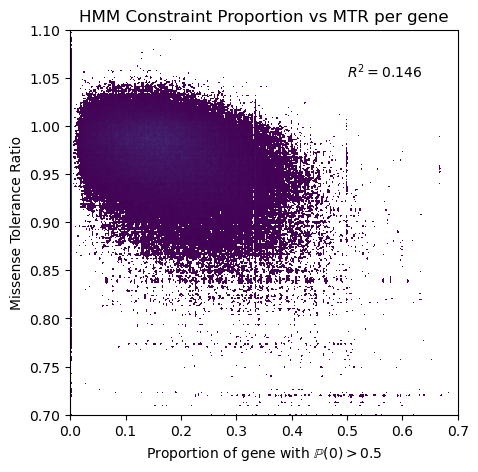

In [46]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='scatter_density')
density = ax.scatter_density(gene_constraint_df['proportion_over_50'], gene_constraint_df['MTR'], cmap=white_viridis)
ax.set_xlabel('Proportion of gene with $\mathbb{P}(0) > 0.5$')
ax.set_ylabel('Missense Tolerance Ratio')
# ax.set_ylabel('Z-score of observed vs expected')
ax.set_xlim([0, 0.7])  # Adjust xlim if needed
ax.set_ylim([0.7, 1.1])   # Adjust ylim if needed
ax.set_title('HMM Constraint Proportion vs MTR per gene')
# ax.set_title('HMM Constraint Predictions vs gnomAD Z-score per gene')
# fig.colorbar(density, label='Number of points per pixel')
ax.text(0.5, 1.05, f'$R^2={round(rsquared,3)}$', fontsize=10)
plt.savefig(results_path + "Figure 3c: HMM vs MTR per gene")
plt.show()